In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
GRID_SIZE = 5
GAMMA = 0.9

ACTION = [
    (-1,0), (0,1),
    (1,0), (0,-1),
    (0,0)
    ]
ACTION_SYMBOLS = [
    '↑', '→',
    '↓', '←',
    'O'
    ]
GOAL_STATE = (3, 2)

OBSTACLE = [
    (1,1), (1,2),
    (2,2),
    (3,1), (3,3),
    (4,1)
]

obstacle_through = True
Epsilon = 0.1
ALPHA = 0.1
num_episodes = 1000
max_steps = 20



In [22]:
"""
状态转移函数
"""

def step(state, action_idx, ACTION, obstacle_through=False):
    """
    返回: next_state, reward
    """
    if state == GOAL_STATE:
        return state, 1.0
    
    # print(f"当前状态: {state}, 执行动作: {ACTION_SYMBOLS[action_idx]}")
    r, c = state
    dr, dc = ACTION[action_idx]
    next_r, next_c = r + dr, c + dc

    # 检查边界
    if next_r < 0 or next_r >= GRID_SIZE or next_c < 0 or next_c >= GRID_SIZE:
        return state, -1.0 # 撞墙: 奖励-1，留在原地
    
    next_state = (next_r, next_c)

    # 检查障碍物
    if obstacle_through:
        if next_state in OBSTACLE:
            return next_state, -10.0
    else:
        if next_state in OBSTACLE:
            return state, -10.0 # 撞障碍物: 奖励-10，留在原地; 如果允许穿过障碍物，则为返回next_state
    
    # 正常状态转移
    if next_state == GOAL_STATE:
        return next_state, 1.0 # 到达目标状态: 奖励1
    else:
        return next_state, -0.1

"""
epsilon-greedy 策略
"""
def get_epsilon_greedy_action(q_value, epsilon):
    if np.random.rand() < epsilon:
        # 探索: 以 epsilon 的概率随机选择一个动作
        return np.random.randint(len(q_value))  # 随机选择一个动作
    else:
        return np.argmax(q_value)


"""
提取最优策略 (Policy Extraction)
"""
def extract_policy(GRID_SIZE, OBSTACLE, Q_final, obstacle_through=True):
    final_policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    final_V = np.zeros((GRID_SIZE, GRID_SIZE))
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if (i, j) in OBSTACLE and not obstacle_through:
                continue 
            
            # 提取最大 Q 值对应的动作 (argmax)
            final_policy[i, j] = np.argmax(Q_final[i, j])
            # 提取最大 Q 值作为该格子的状态价值 V(s) (max)
            final_V[i, j] = np.max(Q_final[i, j])
    
    return final_policy, final_V


In [23]:
"""
可视化 (Heatmap & Policy Arrows)
"""
def visualize_grid(V, policy, Epsilon, OBSTACLE, obstacle_through=False):
    plt.figure(figsize=(8, 6))
    
    V_plot = np.copy(V)
    # 只有在不允许穿透时，才把障碍物设为 NaN 挖空（显示为背景色）
    # 如果允许穿透，我们要保留它惨烈的负分，让热力图显示出来
    if not obstacle_through:
        for (r, c) in OBSTACLE:
            V_plot[r, c] = np.nan
        
    ax = sns.heatmap(V_plot, annot=True, fmt=".2f", cmap="YlGnBu", 
                     linewidths=.5, cbar_kws={'label': 'State Value $V(s)$'})
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if not obstacle_through and state in OBSTACLE:
                # 不可穿透的墙，画上灰色大方块
                ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='gray', fontsize=20)
            
            elif state == GOAL_STATE:
                # 终点
                symbol = ACTION_SYMBOLS[policy[i, j]]
                ax.text(j + 0.5, i + 0.8, f"GOAL({symbol})", ha='center', va='center', color='red', weight='bold')
            
            else:
                symbol = ACTION_SYMBOLS[policy[i, j]]
                
                # 如果允许穿透，给障碍物格子加上特殊的色和紫色箭头
                if obstacle_through and state in OBSTACLE:
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='purple', fontsize=18, weight='bold')
                    ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='red', alpha=0.3, fontsize=20)
                else:
                    # 正常平地
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='black', fontsize=16, weight='bold')
                
    plt.title(f"MC Control ($\gamma$={GAMMA}, $\epsilon$={Epsilon}) | Obstacle Through: {obstacle_through}")
    plt.show()

def plot_learning_curve(learning_curve, window_size=100):
    """
    繪製學習曲線，包含原始回報和滑動平均回報
    """
    plt.figure(figsize=(10, 6))
    
    # 1. 繪製原始數據 (淺藍色，透明度低，用於觀察波動範圍)
    plt.plot(learning_curve, color='blue', alpha=0.2, label='Raw Total Reward')
    
    # 2. 計算並繪製滑動平均線 (紅色，較粗，用於觀察收斂趨勢)
    # 只有當 episode 數量大於窗口大小時才計算
    if len(learning_curve) >= window_size:
        # 使用 np.convolve 快速計算滑動平均
        moving_avg = np.convolve(learning_curve, np.ones(window_size)/window_size, mode='valid')
        # x 軸需要對齊，因為 valid 模式會砍掉前面的 window_size - 1 個點
        x_axis = np.arange(window_size - 1, len(learning_curve))
        plt.plot(x_axis, moving_avg, color='red', linewidth=2.5, label=f'Moving Average')
        
    plt.title('Monte Carlo Control Learning Curve', fontsize=16)
    plt.xlabel('Episode', fontsize=14)
    plt.ylabel('Total Reward per Episode', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()



In [24]:
"""
Q-learning (off-policy) 算法实现 使用到数据为 (s_t, a_t, r_{t+1}, s_{t+1}) 的单步数据
Update q-value using the formula:
  q_{t+1}(s_t, a_t) = q_t(s_t, a_t) - alpha_t(s_t, a_t)*[q_t(s_t, a_t) - [r_{t+1} + gamma*max_a q_t(s_{t+1}, a)]]
Solving the Bellman optimality equation
Behavior policy 代表机器人移动试错policy : maximizing (greedy) policy derived from Q (with epsilon-greedy exploration)
Target policy 代表最终学到的完美policy : greedy policy derived from Q (the optimal policy we want to learn)

"""

def q_learning(Q, Epsilon, num_episodes, max_steps, GRID_SIZE, GOAL_STATE, OBSTACLE, ACTION, GAMMA, ALPHA, obstacle_through=False):
    
    return_history = []

    for ep in range(num_episodes):

      # 随机初始化起点
        while True:
            r = np.random.randint(GRID_SIZE)
            c = np.random.randint(GRID_SIZE)
            state = (r, c)
            if state == GOAL_STATE:
                continue
            if not obstacle_through and state in OBSTACLE:
                continue
            break

        episode_total_reward = 0.0

        for _ in range(max_steps):
            # 试错过程：选择动作: epsilon-greedy
            action = get_epsilon_greedy_action(Q[state], Epsilon)

            # 执行动作，观察奖励和下一个状态
            next_state, reward = step(state, action, ACTION, obstacle_through)
            episode_total_reward += reward

            # 计算最大 q_t(s_{t+1}, a) 用于更新
            r, c = state
            current_q = Q[r, c, action]
            
            if next_state == GOAL_STATE:
              max_next_q = 0.0
            else:
              # 直接取最大值，不考虑 epsilon-greedy  Q[next_state] 是一个动作维度的数组，取最大值
              max_next_q = np.max(Q[next_state])

            # Q-learning 更新公式
            TD_target = reward + GAMMA * max_next_q
            TD_error = current_q -TD_target
            Q[r, c, action] -= ALPHA * TD_error

            # 转移到下一个状态
            if next_state == GOAL_STATE:
              break

            state = next_state
          
        return_history.append(episode_total_reward)
  
    return Q, return_history

In [25]:
Q_init_q_learning = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTION)))  # Q(s, a) 初始化为全零
Q_final_q_learning, return_history_q_learning = q_learning(
    Q_init_q_learning, Epsilon, num_episodes, max_steps, 
    GRID_SIZE, GOAL_STATE, OBSTACLE, ACTION, GAMMA, ALPHA, 
    obstacle_through
    )

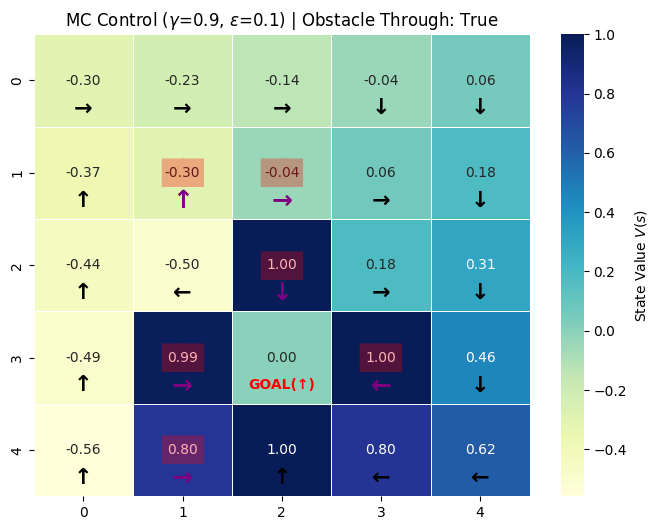

In [26]:
final_policy_q_learning, final_V_q_learning = extract_policy(GRID_SIZE, OBSTACLE, Q_final_q_learning, obstacle_through)
visualize_grid(final_V_q_learning, final_policy_q_learning, Epsilon, OBSTACLE, obstacle_through)

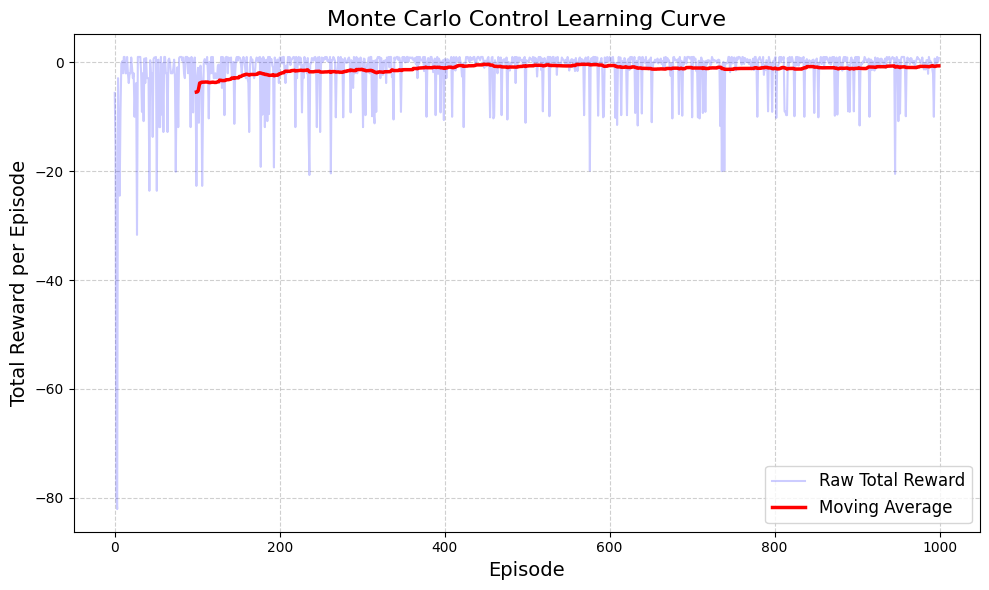

In [27]:
plot_learning_curve(return_history_q_learning, window_size=100)